In [1]:
import pandas as pd 
df = pd.read_csv('insurance.csv')
print("first 5 row")
print(df.head())

first 5 row
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [2]:
print("data info")
df.info()

data info
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [3]:
print("descriptive statistics")
df.describe()

descriptive statistics


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
print("missing values count")
print(df.isnull().sum())

missing values count
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


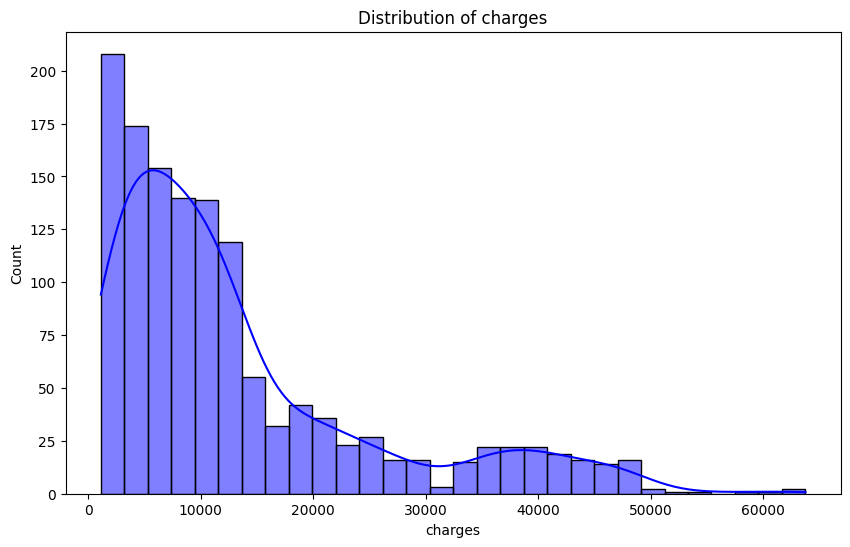

In [8]:
import seaborn as sns 
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,6))
sns.histplot(df['charges'], kde=True ,color ='blue')
plt.title('Distribution of charges')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_13724\2525452492.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges' ,data =df ,palette='Set2')


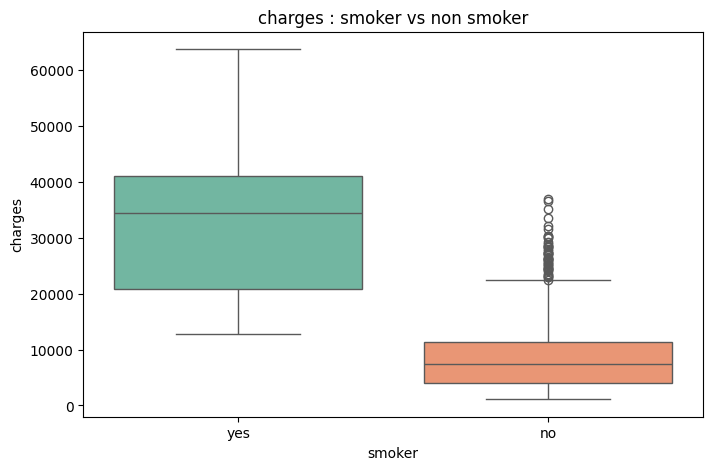

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges' ,data =df ,palette='Set2')
plt.title('charges : smoker vs non smoker')
plt.show()

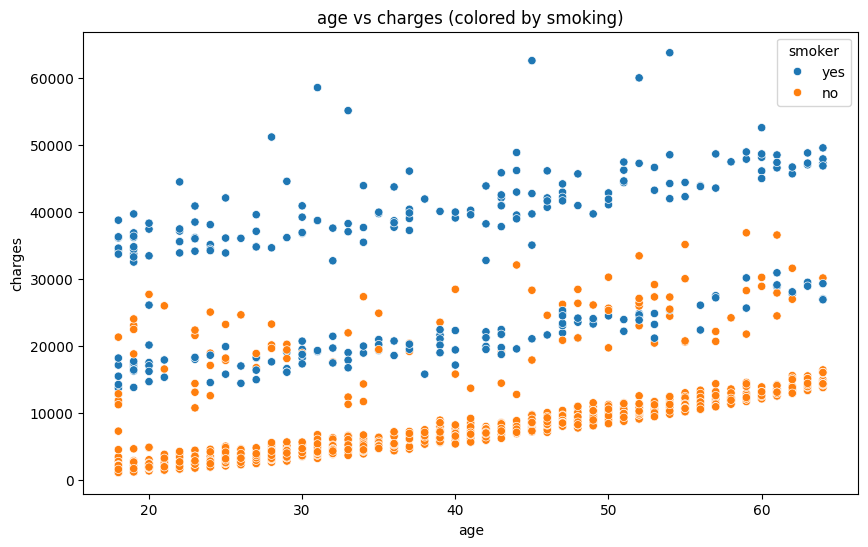

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='age',y='charges' ,hue ='smoker'  ,data =df)
plt.title('age vs charges (colored by smoking)')
plt.show()

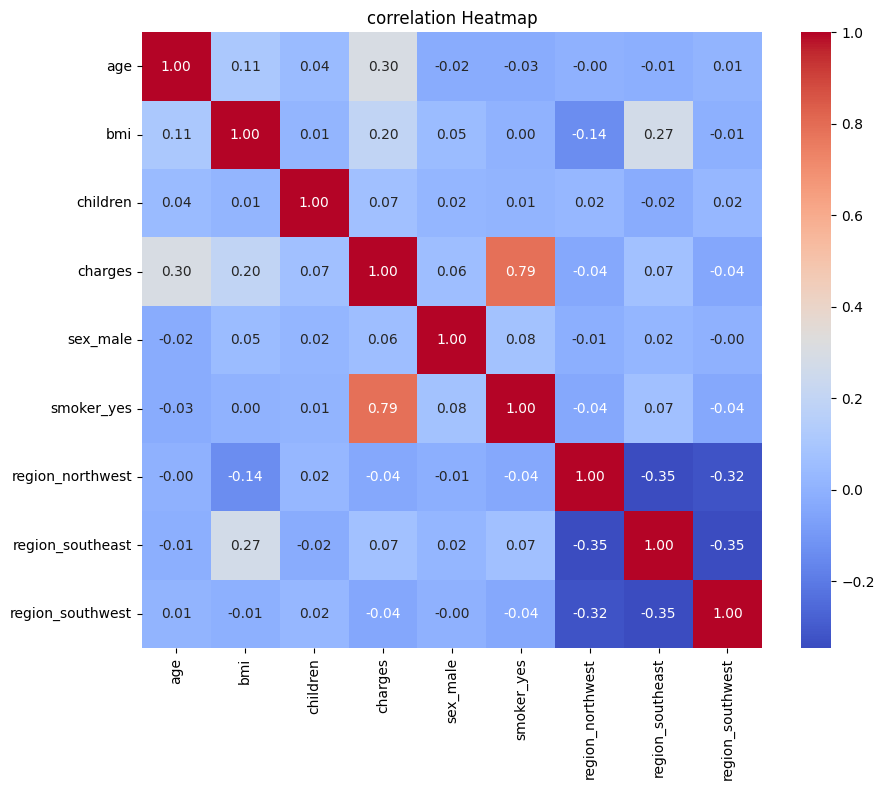

In [13]:
#encoding
df_encoded = pd.get_dummies(df,drop_first =True)
#correlation
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('correlation Heatmap')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score
x = df_encoded.drop('charges', axis =1)
y = df_encoded['charges']
x_train , x_test , y_train ,y_test = train_test_split(x ,y ,test_size=0.2, random_state=42)
model =LinearRegression()
model.fit(x_train,y_train)
y_pred =model.predict(x_test)
score = r2_score(y_test,y_pred)
print(f"model accuracy r2 score: {score}")

model accuracy r2 score: 0.7835929767120723


In [19]:
df_fe = df_encoded.copy()
df_fe['bmi_smoker']= df_fe['bmi']*df_fe['smoker_yes']
print(df_fe[['bmi','smoker_yes','bmi_smoker']].head())


      bmi  smoker_yes  bmi_smoker
0  27.900        True        27.9
1  33.770       False         0.0
2  33.000       False         0.0
3  22.705       False         0.0
4  28.880       False         0.0


In [22]:
x_fe =df_fe.drop('charges',axis =1)
y_fe =df_fe['charges']
x_train_fe, x_test_fe, y_train_fe, y_test_fe = train_test_split(x_fe,y_fe,test_size=0.2,random_state=42)
model_fe = LinearRegression()
model_fe.fit(x_train_fe,y_train_fe)
y_pred_fe = model_fe.predict(x_test_fe)
new_score = r2_score(y_test_fe,y_pred_fe)
print(f"Old Score: 0.7826")
print(f"New Score after Feature Engineering: {new_score:.4f}")

Old Score: 0.7826
New Score after Feature Engineering: 0.8653


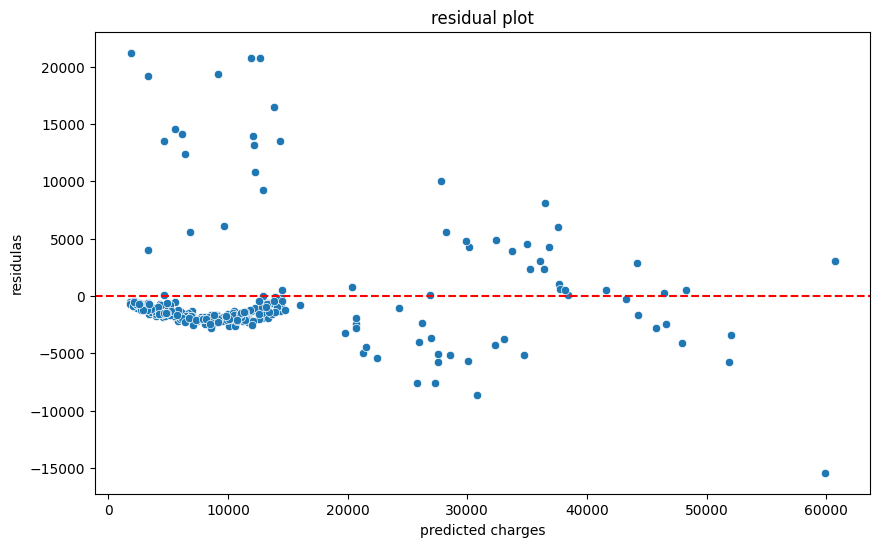

In [23]:
residulas = y_test_fe - y_pred_fe
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred_fe,y=residulas)
plt.axhline(y=0,color ='r',linestyle ='--')
plt.xlabel('predicted charges')
plt.ylabel("residulas")
plt.title("residual plot")
plt.show()

In [25]:
from sklearn.ensemble import RandomForestRegressor
rf_model =RandomForestRegressor(n_estimators=100 ,random_state=42)
rf_model.fit(x_train_fe,y_train_fe)
y_pred_rf =rf_model.predict(x_test_fe)
rf_score =r2_score(y_test_fe,y_pred_rf)
print(f"Linear Regression Score: {new_score:.4f}")
print(f"Random Forest Score: {rf_score:.4f}")

Linear Regression Score: 0.8653
Random Forest Score: 0.8650


In [26]:
import joblib

joblib.dump(model_fe, 'insurance_model.pkl')
print("Model saved.")

Model saved.
